# 01 — Exploratory Data Analysis

**Goal:** understand the Kaggle *Game Recommendations on Steam* data well enough to make the open design decisions:

1. **Filter thresholds:** how much does the data shrink at different minimum-review cutoffs for users and games?
2. **Content coverage:** how many games have tags and descriptions?
3. **Confidence weighting:** what does the distribution of hours played look like?
4. **Adult-content filter:** how many games would the blocklist remove?
5. **Serving size:** will the serving bundle fit Render's 512 MB?

Findings feed `params.yaml` and `docs/design-decisions.md`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from steamrec.data import load_games, load_metadata, load_recommendations

REPO_ROOT = Path.cwd().parent
RAW_DIR = REPO_ROOT / "data" / "raw"

# One colour for single-series charts, quiet axes and grid.
BAR_COLOUR = "#2a78d6"
plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.facecolor": "#fcfcfb",
    "figure.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": True,
    "grid.color": "#e6e5e0",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load the raw files

In [2]:
games = load_games(RAW_DIR)
metadata = load_metadata(RAW_DIR)
recommendations = load_recommendations(RAW_DIR)

for name, frame in [("games", games), ("metadata", metadata), ("recommendations", recommendations)]:
    memory_mb = frame.memory_usage(deep=True).sum() / 1_000_000
    print(f"{name:16s} rows={len(frame):>12,}  memory={memory_mb:>8,.1f} MB")

games            rows=      50,872  memory=     2.9 MB
metadata         rows=      50,872  memory=    18.0 MB
recommendations  rows=  41,154,794  memory=   535.0 MB


In [3]:
games.head()

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,True


In [4]:
metadata.head()

,app_id,description,tags
0,13500,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre..."
1,22364,,[Action]
2,113020,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
3,226560,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P..."
4,249050,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."


In [5]:
recommendations.head()

,app_id,is_recommended,hours,user_id
0,975370,True,36.30,51580
1,304390,False,11.50,2586
2,1085660,True,336.50,253880
3,703080,True,27.40,259432
4,526870,True,7.90,23869


## 2. Data quality checks

In [6]:
print("duplicate app_ids in games:   ", games["app_id"].duplicated().sum())
print("duplicate app_ids in metadata:", metadata["app_id"].duplicated().sum())

pair_duplicates = recommendations.duplicated(subset=["user_id", "app_id"]).sum()
print("duplicate (user_id, app_id) reviews:", pair_duplicates)

games_without_metadata = ~games["app_id"].isin(metadata["app_id"])
print("games missing from metadata:", games_without_metadata.sum())

reviews_for_unknown_games = ~recommendations["app_id"].isin(games["app_id"])
print("reviews for games not in games.csv:", reviews_for_unknown_games.sum())

print()
print("missing values in recommendations:")
print(recommendations.isna().sum())

duplicate app_ids in games:    0
duplicate app_ids in metadata: 0


duplicate (user_id, app_id) reviews: 21
games missing from metadata: 0


reviews for games not in games.csv: 0

missing values in recommendations:


app_id            0
is_recommended    0
hours             0
user_id           0
dtype: int64


## 3. Content coverage: tags and descriptions

In [7]:
tag_counts_per_game = metadata["tags"].str.len()
has_tags = tag_counts_per_game > 0
has_description = metadata["description"].str.strip().str.len() > 0
has_both = has_tags & has_description

total = len(metadata)
print(f"games with tags:        {has_tags.sum():>7,} / {total:,}  ({has_tags.mean():.1%})")
print(f"games with description: {has_description.sum():>7,} / {total:,}  ({has_description.mean():.1%})")
print(f"games with both:        {has_both.sum():>7,} / {total:,}  ({has_both.mean():.1%})")
print()
print("tags per game (games that have tags):")
print(tag_counts_per_game[has_tags].describe())

games with tags:         49,628 / 50,872  (97.6%)
games with description:  40,499 / 50,872  (79.6%)
games with both:         40,484 / 50,872  (79.6%)

tags per game (games that have tags):
count   49,628.00
mean        11.77
std          7.11
min          1.00
25%          5.00
50%         12.00
75%         20.00
max         20.00
Name: tags, dtype: float64


In [8]:
description_words = metadata.loc[has_description, "description"].str.split().str.len()
print("description length in words:")
print(description_words.describe())

description length in words:
count   40,499.00
mean        33.40
std         13.58
min          1.00
25%         24.00
50%         35.00
75%         44.00
max         79.00
Name: description, dtype: float64


distinct tags: 441


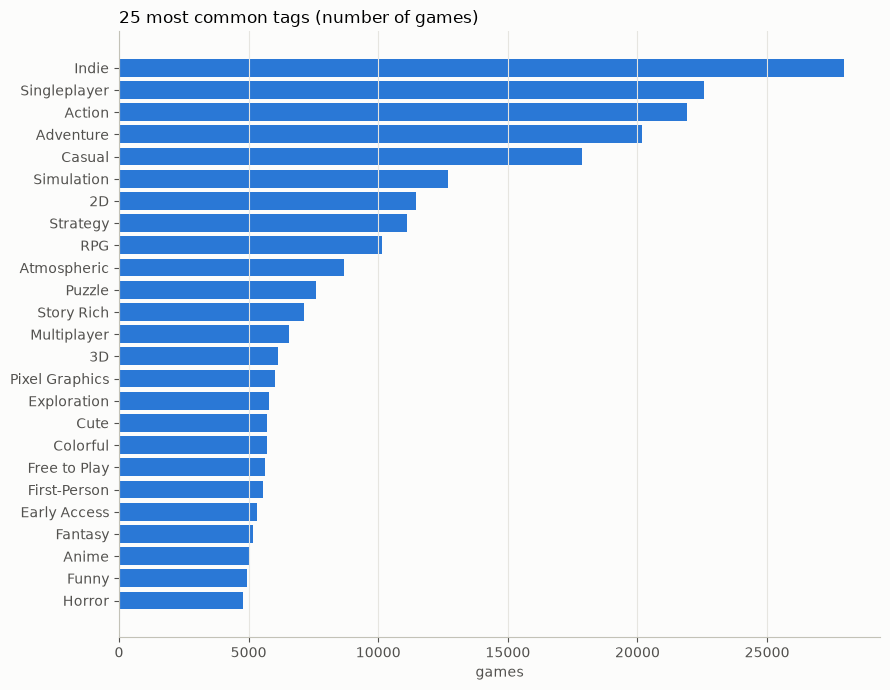

In [9]:
all_tags = metadata["tags"].explode().dropna()
tag_frequency = all_tags.value_counts()
print(f"distinct tags: {len(tag_frequency):,}")

top_tags = tag_frequency.head(25).sort_values()
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_tags.index, top_tags.values, color=BAR_COLOUR)
ax.set_title("25 most common tags (number of games)", loc="left")
ax.set_xlabel("games")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Adult-content blocklist

Candidate tags for the blocklist. Counted on the whole catalogue and on reviewed games.

In [10]:
ADULT_TAGS = ["Sexual Content", "Nudity", "NSFW", "Hentai", "Mature"]

for tag in ADULT_TAGS:
    count = int(tag_frequency.get(tag, 0))
    print(f"{tag:16s} {count:>6,} games")

# One row per (game, tag) pair, so we can test each tag with isin.
tags_long = metadata[["app_id", "tags"]].explode("tags")
is_adult_tag = tags_long["tags"].isin(ADULT_TAGS)
adult_app_ids = tags_long.loc[is_adult_tag, "app_id"].unique()

adult_reviews = recommendations["app_id"].isin(adult_app_ids)
print()
print(f"games with any blocklisted tag: {len(adult_app_ids):,} ({len(adult_app_ids) / total:.1%})")
print(f"reviews of those games:         {adult_reviews.sum():,} ({adult_reviews.mean():.1%})")

Sexual Content    2,294 games
Nudity            2,272 games
NSFW                407 games
Hentai              647 games
Mature              979 games



games with any blocklisted tag: 3,333 (6.6%)
reviews of those games:         3,447,073 (8.4%)


In [11]:
# Most-reviewed games carrying each tag: checks whether a tag is too broad to block.
reviews_per_app = recommendations.groupby("app_id").size().rename("reviews")
titles = games.set_index("app_id")["title"]

for tag in ADULT_TAGS:
    tagged_app_ids = tags_long.loc[tags_long["tags"] == tag, "app_id"]
    top = reviews_per_app.reindex(tagged_app_ids).dropna().nlargest(5)
    top_titles = titles.reindex(top.index).tolist()
    print(f"{tag}: {top_titles}")

Sexual Content: ['鬼谷八荒 Tale of Immortal', 'OUTRIDERS', 'FIFA 22', 'Watch_Dogs® 2', 'Yakuza 0']
Nudity: ['Crab Game', 'Far Cry 3', 'The Witcher 2: Assassins of Kings Enhanced Edition', 'Everlasting Summer', "The Witcher: Enhanced Edition Director's Cut"]
NSFW: ['Tricolour Lovestory', 'NEKOPARA Vol. 1', 'Soul Dossier', 'Senren＊Banka', 'Sakura Clicker']
Hentai: ['Tricolour Lovestory', 'NEKOPARA Vol. 1', 'Helltaker', 'NEKOPARA Vol. 0', 'Soul Dossier']
Mature: ['Dota Underlords', 'POSTAL 2', 'The Witcher 2: Assassins of Kings Enhanced Edition', 'Everlasting Summer', 'Metro 2033 Redux']


## 4. Interactions: positive vs negative, hours played

In [12]:
positive_share = recommendations["is_recommended"].mean()
print(f"positive reviews: {positive_share:.1%}")
print(f"negative reviews: {1 - positive_share:.1%}")
print()
print("hours played:")
print(recommendations["hours"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]))
print()
print("reviews with 0 hours:", (recommendations["hours"] == 0).sum())
print("most common maximum values:")
print(recommendations["hours"].nlargest(5).values)

positive reviews: 85.8%
negative reviews: 14.2%

hours played:


count   41,154,794.00
mean           100.60
std            176.17
min              0.00
10%              2.10
25%              7.80
50%             27.30
75%             99.20
90%            304.00
99%            864.50
max          1,000.00
Name: hours, dtype: float64

reviews with 0 hours: 176329
most common maximum values:


[1000. 1000. 1000. 1000. 1000.]


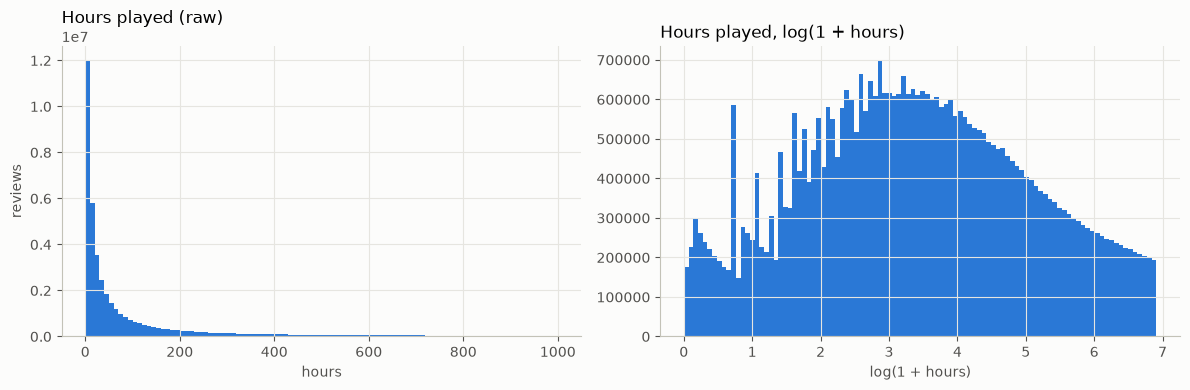

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(recommendations["hours"], bins=100, color=BAR_COLOUR)
axes[0].set_title("Hours played (raw)", loc="left")
axes[0].set_xlabel("hours")
axes[0].set_ylabel("reviews")

log_hours = np.log1p(recommendations["hours"])
axes[1].hist(log_hours, bins=100, color=BAR_COLOUR)
axes[1].set_title("Hours played, log(1 + hours)", loc="left")
axes[1].set_xlabel("log(1 + hours)")

plt.tight_layout()
plt.show()

In [14]:
median_hours_by_label = recommendations.groupby("is_recommended")["hours"].median()
print("median hours, by review label:")
print(median_hours_by_label)

median hours, by review label:
is_recommended
False   11.10
True    30.30
Name: hours, dtype: float32


## 5. Activity: reviews per user and per game

Collaborative filtering only uses **positive** reviews, so activity is counted on positive reviews.

In [15]:
positive = recommendations[recommendations["is_recommended"]]
print(f"positive reviews: {len(positive):,}")

reviews_per_user = positive.groupby("user_id").size()
reviews_per_game = positive.groupby("app_id").size()

percentiles = [0.25, 0.5, 0.75, 0.9, 0.99]
print()
print("positive reviews per user:")
print(reviews_per_user.describe(percentiles=percentiles))
print()
print("positive reviews per game:")
print(reviews_per_game.describe(percentiles=percentiles))

positive reviews: 35,304,398



positive reviews per user:


count   12,663,134.00
mean             2.79
std              6.76
min              1.00
25%              1.00
50%              1.00
75%              3.00
90%              5.00
99%             22.00
max          3,920.00
dtype: float64

positive reviews per game:
count    37,419.00
mean        943.49
std       6,725.93
min           1.00
25%          10.00
50%          29.00
75%         139.00
90%         797.00
99%      20,194.22
max     294,879.00
dtype: float64


In [16]:
for cutoff in [1, 2, 3, 5, 10, 20]:
    users_at_least = (reviews_per_user >= cutoff).sum()
    share = users_at_least / len(reviews_per_user)
    print(f"users with >= {cutoff:>2} positive reviews: {users_at_least:>10,}  ({share:.1%})")

users with >=  1 positive reviews: 12,663,134  (100.0%)
users with >=  2 positive reviews:  5,548,063  (43.8%)
users with >=  3 positive reviews:  3,304,348  (26.1%)
users with >=  5 positive reviews:  1,624,066  (12.8%)
users with >= 10 positive reviews:    548,339  (4.3%)
users with >= 20 positive reviews:    162,033  (1.3%)


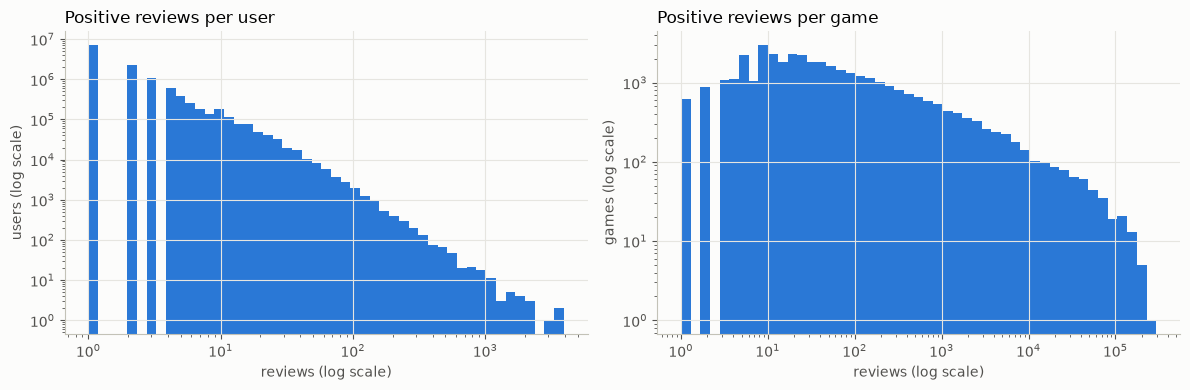

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

user_bins = np.logspace(0, np.log10(reviews_per_user.max()), 50)
axes[0].hist(reviews_per_user, bins=user_bins, color=BAR_COLOUR)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Positive reviews per user", loc="left")
axes[0].set_xlabel("reviews (log scale)")
axes[0].set_ylabel("users (log scale)")

game_bins = np.logspace(0, np.log10(reviews_per_game.max()), 50)
axes[1].hist(reviews_per_game, bins=game_bins, color=BAR_COLOUR)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Positive reviews per game", loc="left")
axes[1].set_xlabel("reviews (log scale)")
axes[1].set_ylabel("games (log scale)")

plt.tight_layout()
plt.show()

## 6. Filter threshold grid

For each pair of thresholds we keep users with at least `min_user_reviews` positive reviews,
then keep games with at least `min_game_reviews` positive reviews **among those users**
(one pass, users first). We report what remains.

Counting uses `np.bincount` on the id arrays, which is fast enough to try many combinations.

In [18]:
user_ids = positive["user_id"].to_numpy()
app_ids = positive["app_id"].to_numpy()

# (max_user_id + 1,): positive reviews per user, indexed by user_id
user_review_counts = np.bincount(user_ids)


def apply_thresholds(min_user_reviews: int, min_game_reviews: int) -> dict:
    """Keep active users, then games popular among them; return what remains."""
    # (n_reviews,): True where the reviewer is an active user
    keep_user = user_review_counts[user_ids] >= min_user_reviews
    kept_app_ids = app_ids[keep_user]

    # (max_app_id + 1,): positive reviews per game, counted among active users only
    game_review_counts = np.bincount(kept_app_ids)
    # (n_kept_reviews,): True where the game is popular enough
    keep_game = game_review_counts[kept_app_ids] >= min_game_reviews

    kept_users = np.unique(user_ids[keep_user][keep_game])
    kept_games = np.unique(kept_app_ids[keep_game])
    n_interactions = int(keep_game.sum())
    density = n_interactions / (len(kept_users) * len(kept_games))

    return {
        "min_user_reviews": min_user_reviews,
        "min_game_reviews": min_game_reviews,
        "interactions": n_interactions,
        "users": len(kept_users),
        "games": len(kept_games),
        "share_of_positive": n_interactions / len(user_ids),
        "density_%": density * 100,
    }


rows = []
for min_user_reviews in [1, 3, 5, 10, 20]:
    for min_game_reviews in [10, 50, 100, 500]:
        rows.append(apply_thresholds(min_user_reviews, min_game_reviews))

threshold_grid = pd.DataFrame(rows)
threshold_grid.style.format({
    "interactions": "{:,}",
    "users": "{:,}",
    "games": "{:,}",
    "share_of_positive": "{:.1%}",
    "density_%": "{:.3f}",
})

,min_user_reviews,min_game_reviews,interactions,users,games,share_of_positive,density_%
0,1,10,"35,257,460","12,659,175","28,385",99.9%,0.010
1,1,50,"34,947,587","12,635,726","14,890",99.0%,0.019
2,1,100,"34,668,446","12,611,774","10,944",98.2%,0.025
3,1,500,"33,281,805","12,469,689","4,841",94.3%,0.055
4,3,10,"23,651,033","3,304,339","27,069",67.0%,0.026
5,3,50,"23,349,632","3,304,100","13,904",66.1%,0.051
6,3,100,"23,080,954","3,303,825","10,106",65.4%,0.069
7,3,500,"21,771,069","3,301,228","4,288",61.7%,0.154
8,5,10,"17,996,655","1,624,064","26,115",51.0%,0.042
9,5,50,"17,702,167","1,624,015","13,160",50.1%,0.083


## 7. Serving size estimate (Render: 512 MB RAM)

Rough size of the main serving artefacts, for a catalogue of `n_games` games.
Each stored neighbour costs one `int32` index + one `float32` score = 8 bytes.

In [19]:
n_catalogue = int(has_both.sum())
n_cf_games = int(threshold_grid.loc[
    (threshold_grid["min_user_reviews"] == 5) & (threshold_grid["min_game_reviews"] == 50), "games"
].iloc[0])

BYTES_PER_NEIGHBOUR = 8
for k in [50, 100, 200]:
    cf_mb = n_cf_games * k * BYTES_PER_NEIGHBOUR / 1_000_000
    content_mb = n_catalogue * k * BYTES_PER_NEIGHBOUR / 1_000_000
    print(f"K={k:>3}: CF neighbours {cf_mb:6.1f} MB  |  content neighbours {content_mb:6.1f} MB")

embeddings_mb = n_catalogue * 384 * 2 / 1_000_000
print(f"\nfull description embeddings (float16, 384 dims): {embeddings_mb:.1f} MB")

K= 50: CF neighbours    5.3 MB  |  content neighbours   16.2 MB
K=100: CF neighbours   10.5 MB  |  content neighbours   32.4 MB
K=200: CF neighbours   21.1 MB  |  content neighbours   64.8 MB

full description embeddings (float16, 384 dims): 31.1 MB


## 8. Findings

**Data quality**
- 50,872 games, 41.2M reviews, 12.7M users with at least one positive review. Every review's `app_id` exists in `games.csv`, and every game has a metadata row.
- **21 duplicate `(user_id, app_id)` reviews.** Drop them in the `filter` stage.
- `hours` is **capped at 1,000** in the source data, and 176k reviews have 0 hours. `log(1 + hours)` handles both.
- With explicit dtypes the 41M-row table uses **535 MB** of memory, so plain pandas is fine.

**Content coverage**
- **Tags: 97.6% of games**, 441 distinct tags, **at most 20 per game** (median 12). The tag list has no vote counts.
- **Descriptions: only 79.6% of games** and they're short (median 35 words), so tags are the main content signal. Descriptions add to it where they exist.

**Interactions**
- 85.8% of reviews are positive. Median hours played: **30.3 for positive reviews vs 11.1 for negative**, so hours do carry signal.
- Activity is extremely skewed. **The median user has 1 positive review**. Only 12.8% of users have 5 or more.
- Item-to-item CF learns only from users with **at least 2** positive reviews, because a single review co-occurs with nothing.

**Filter thresholds** (from the grid in section 6)
- `min_user_reviews=5, min_game_reviews=50` keeps **17.7M interactions (50% of positive reviews), 1.62M users and 13,160 games**.
- Raising `min_game_reviews` mainly removes games (14.9k → 4.8k at 500) and barely affects interactions. Raising `min_user_reviews` mainly removes users.

**Adult-content blocklist**
- "Sexual Content", "Nudity" and "Mature" are **too broad**: they catch The Witcher 2, Far Cry 3, Yakuza 0, Watch_Dogs 2 and Metro 2033.
- "NSFW" and "Hentai" target explicit games accurately.

**Serving size**
- With K=100 neighbours: CF ≈ 11 MB, content ≈ 32 MB. Full description embeddings (float16) ≈ 31 MB. **This fits comfortably in Render's 512 MB.**

Decisions based on these findings are recorded in `docs/design-decisions.md` and `params.yaml`.